In [77]:
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
data=load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [79]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df['Target']=data.target

In [80]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [81]:
df.shape

(442, 11)

In [82]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [83]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [84]:
coefs=[]
r2_scores=[]

for i in [0,10,100,1000]:
    reg=Ridge(alpha=i)
    reg.fit(x_train,y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred=reg.predict(x_test)
    r2_scores.append(r2_score(y_test,y_pred))

In [85]:
r2_scores

[0.43993386615689667,
 0.15214327672566985,
 0.010378115936827137,
 -0.010136670498663625]

Text(0.5, 1.0, 'Alpha=1000,r2_score=-0.01')

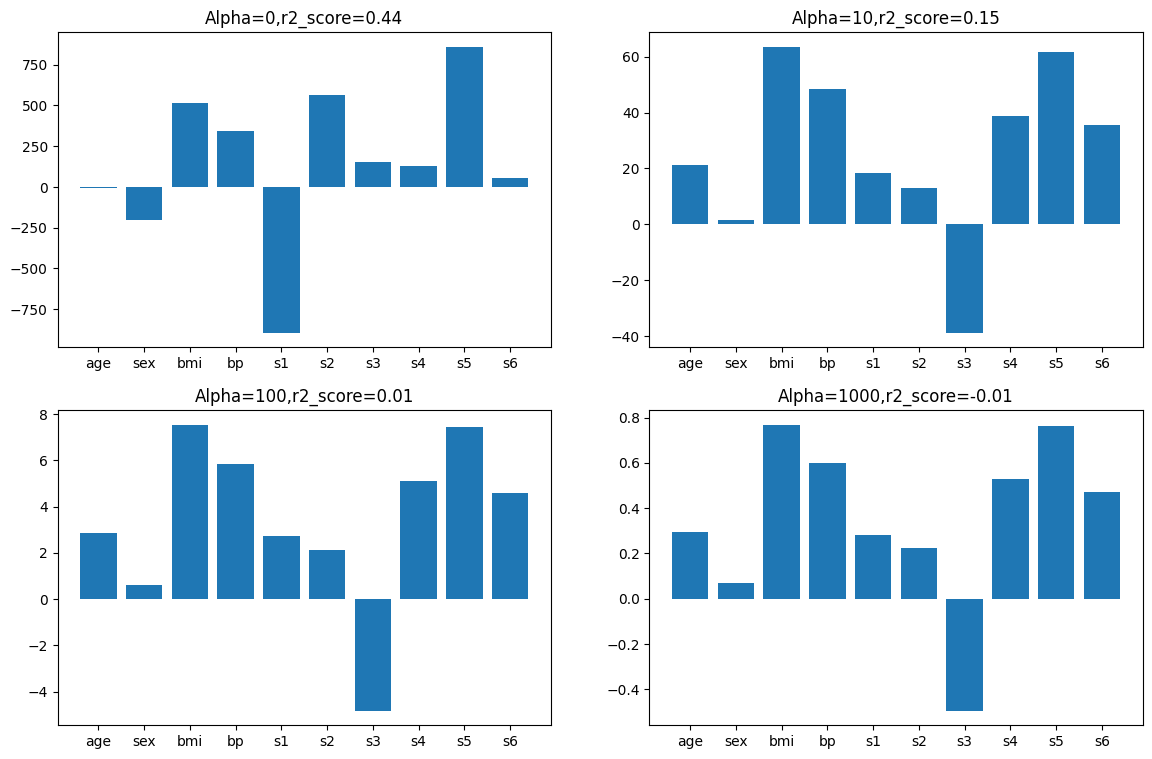

In [86]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title("Alpha=0,r2_score={}".format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title("Alpha=10,r2_score={}".format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title("Alpha=100,r2_score={}".format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title("Alpha=1000,r2_score={}".format(round(r2_scores[3],2)))

In [87]:
coefs=[]
r2_scores=[]
alphas=[0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
for i in alphas :
    reg=Ridge(alpha=i)
    reg.fit(x_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [88]:
input_array=np.array(coefs)

In [89]:
coef_df=pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha']=alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [90]:
len(alphas),input_array[0].shape

(10, (10,))

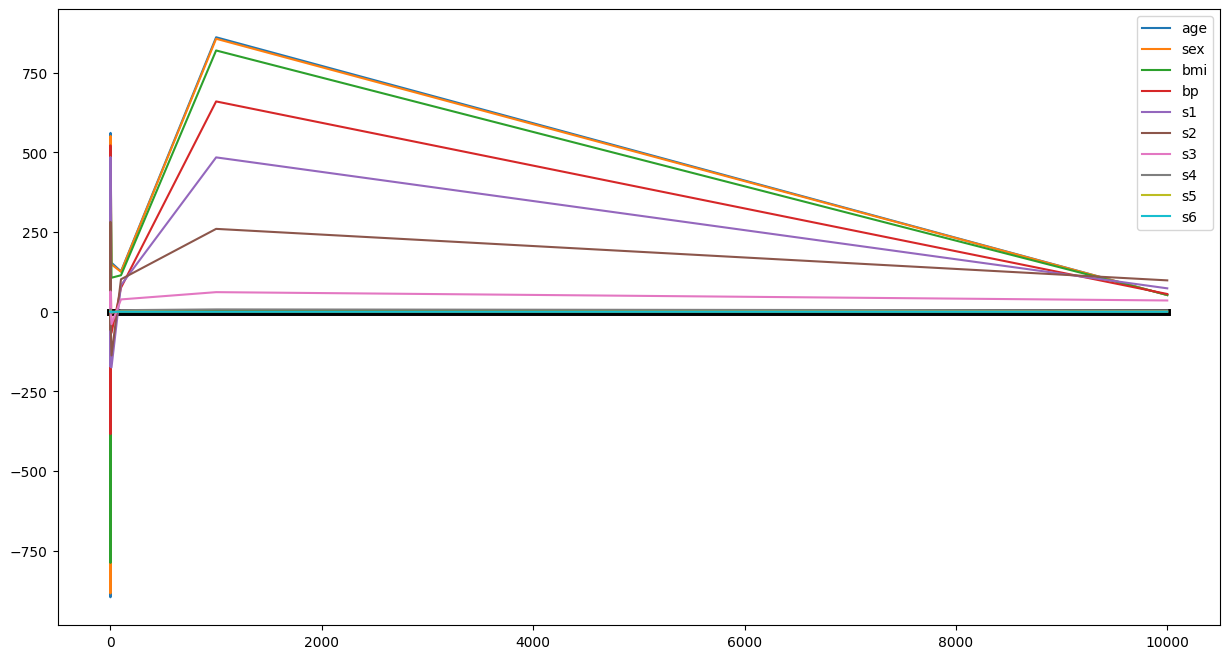

In [91]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

                Impact on bias and Variance

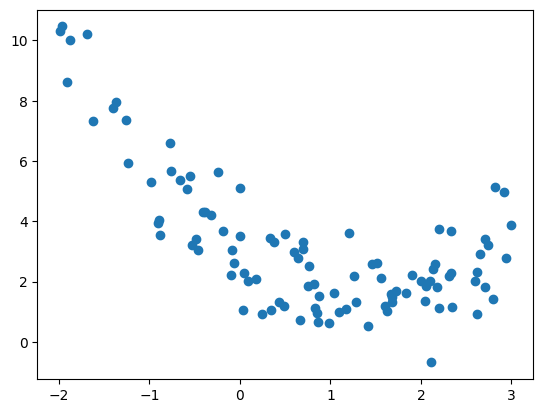

In [98]:
m=100
x=5*np.random.rand(m,1)-2
y=0.7*x**2 - 2*x + 3+np.random.randn(m,1)
plt.scatter(x,y)
plt.show()

In [94]:
x.shape

(100, 1)

In [105]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=2,test_size=0.2)

In [106]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=15)
x_train=poly.fit_transform(x_train)
x_test=poly.transform(x_test)

In [107]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
from mlxtend.evaluate import bias_variance_decomp 

In [111]:
alphas=np.linspace(0,30,100)
loss=[]
bias=[]
variance=[]

for i in alphas:
    reg=Ridge(alpha=i)
    avg_expected_loss,avg_bias,avg_var=bias_variance_decomp(
        reg,x_train,y_train,x_test,y_test,
        loss='mse',
        random_seed=123
    )
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)


ValueError: could not broadcast input array from shape (20,1) into shape (20,)

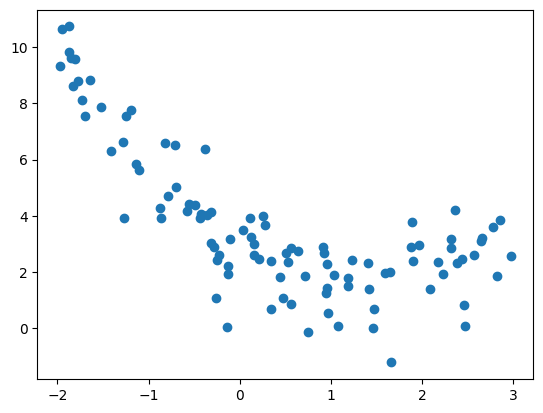

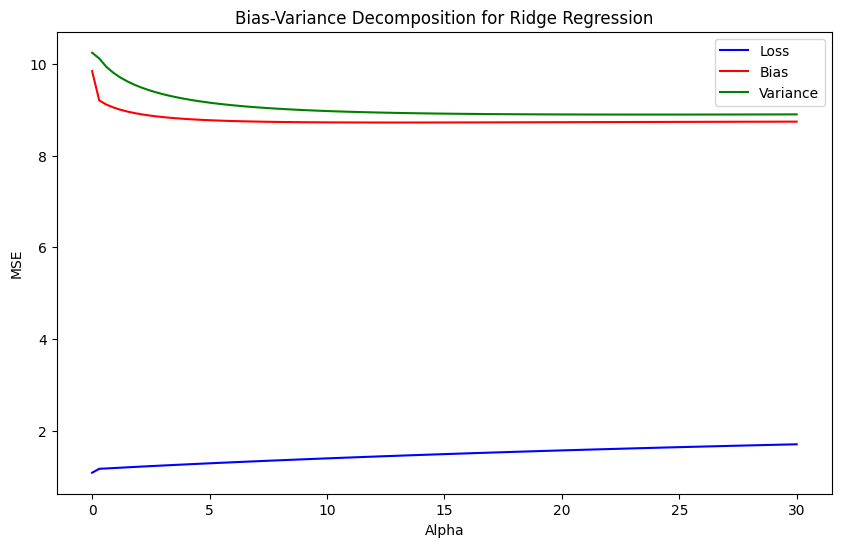

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

# Generate data
m = 100
x = 5 * np.random.rand(m, 1) - 2
y = 0.7 * x**2 - 2 * x + 3 + np.random.randn(m, 1)
plt.scatter(x, y)
plt.show()

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=2, test_size=0.2)

# Polynomial feature transformation
poly = PolynomialFeatures(degree=15)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Ridge regression
alphas = np.linspace(0, 30, 100)
loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    
    # Cross-validated predictions
    y_train_pred = cross_val_predict(reg, x_train_poly, y_train.ravel(), cv=10)
    y_test_pred = reg.fit(x_train_poly, y_train).predict(x_test_poly)

    # Calculate bias and variance
    avg_y_pred = np.mean(y_train_pred)
    bias_val = np.mean((avg_y_pred - y_test) ** 2)
    variance_val = np.mean((y_test_pred - avg_y_pred) ** 2)

    # Store values
    bias.append(bias_val)
    variance.append(variance_val)
    loss.append(mean_squared_error(y_test, y_test_pred))

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(alphas, loss, label="Loss", color="blue")
plt.plot(alphas, bias, label="Bias", color="red")
plt.plot(alphas, variance, label="Variance", color="green")
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Bias-Variance Decomposition for Ridge Regression')
plt.show()
